In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report)
from sklearn.tree import DecisionTreeClassifier
import joblib

import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [102]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [103]:
from google.colab import files
uploaded = files.upload()

Saving archive (6).zip to archive (6) (1).zip
Saving archive (5).zip to archive (5) (1).zip


In [104]:
import zipfile
# first
with zipfile.ZipFile('archive (6).zip', 'r') as zip_ref:
    zip_ref.extractall('dataset1')

# second ZIP
with zipfile.ZipFile('archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('dataset2')

In [105]:
import os

print(os.listdir('dataset1'))
print(os.listdir('dataset2'))

['ai_resume_screening.csv']
['AI_Resume_Screening.csv']


In [106]:
df1 = pd.read_csv('dataset1/ai_resume_screening.csv')
df2 = pd.read_csv('dataset2/AI_Resume_Screening.csv')

In [107]:
df1.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [108]:
df2.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [109]:
df2.tail()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Analyst,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100
999,1000,Chad Collins,"SQL, Machine Learning, Python, Deep Learning",7,M.Tech,Deep Learning Specialization,Data Scientist,Hire,119474,3,100


In [110]:
df2.shape

(1000, 11)

In [111]:
df1.shape

(30000, 7)

In [112]:
df1.size

210000

In [113]:
df2.size

11000

In [114]:
df2.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [115]:
df1.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [116]:
df1.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [117]:
df2.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [118]:
df1.dtypes

,0
years_experience,int64
skills_match_score,float64
education_level,object
project_count,int64
resume_length,int64
github_activity,int64
shortlisted,object


In [119]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [120]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [121]:
df2.describe(include='all')

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000,1000,1000.000000,1000,726,1000,1000,1000.000000,1000.00000,1000.000000
unique,NaN,989,238,NaN,5,3,4,2,NaN,NaN,NaN
top,NaN,Sarah Jones,"Python, Machine Learning",NaN,B.Sc,Deep Learning Specialization,AI Researcher,Hire,NaN,NaN,NaN
freq,NaN,3,11,NaN,205,255,257,812,NaN,NaN,NaN
mean,500.500000,NaN,NaN,4.896000,NaN,NaN,NaN,NaN,79994.486000,5.13300,83.950000
std,288.819436,NaN,NaN,3.112695,NaN,NaN,NaN,NaN,23048.472549,3.23137,20.983036
min,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,40085.000000,0.00000,15.000000
25%,250.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,60415.750000,2.00000,70.000000
50%,500.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,79834.500000,5.00000,100.000000
75%,750.250000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,99583.250000,8.00000,100.000000


In [122]:
df1.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [123]:
df2.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [124]:
df2.duplicated().sum()

np.int64(0)

In [125]:
df1.duplicated().sum()

np.int64(0)

In [126]:
df2.drop_duplicates(inplace=True)

In [127]:
df1.drop_duplicates(inplace=True)

In [128]:
df2['Education'].value_counts()

,count
Education,
B.Sc,205
MBA,202
B.Tech,200
M.Tech,198
PhD,195


In [129]:
df1['resume_length'].value_counts()

,count
resume_length,
900,1026
150,203
599,90
530,77
545,77
...,...
179,3
158,3
152,3


In [130]:
df2['Education'].unique()

array(['B.Sc', 'MBA', 'B.Tech', 'PhD', 'M.Tech'], dtype=object)

In [131]:
df1['resume_length'].unique()

array([234, 502, 753, 529, 754, 575, 516, 335, 462, 592, 571, 577, 693,
       735, 617, 466, 406, 332, 454, 302, 344, 653, 278, 658, 551, 646,
       271, 683, 393, 673, 223, 823, 729, 488, 584, 804, 607, 740, 709,
       750, 747, 662, 517, 562, 716, 900, 699, 667, 810, 682, 389, 434,
       437, 452, 715, 471, 659, 301, 513, 559, 374, 550, 395, 556, 679,
       611, 865, 511, 681, 400, 773, 605, 320, 384, 676, 727, 670, 739,
       507, 730, 390, 287, 576, 307, 530, 564, 420, 523, 553, 388, 415,
       759, 702, 449, 696, 369, 671, 656, 422, 898, 746, 718, 537, 599,
       480, 826, 594, 531, 620, 365, 772, 608, 722, 807, 648, 688, 236,
       767, 842, 444, 743, 590, 169, 625, 515, 719, 830, 665, 439, 328,
       324, 303, 264, 732, 503, 548, 440, 441, 472, 808, 378, 498, 790,
       546, 308, 582, 326, 534, 394, 581, 380, 792, 296, 150, 783, 447,
       687, 469, 755, 652, 591, 879, 504, 593, 414, 334, 508, 426, 478,
       579, 522, 348, 723, 694, 684, 424, 776, 641, 583, 267, 75

In [132]:
df2['Education'].nunique()

5

In [133]:
df1['resume_length'].nunique()

751

In [134]:
df2.sample()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
519,520,Elizabeth Mcmillan,"C++, React, SQL",9,PhD,Google ML,Software Engineer,Hire,113497,5,100


In [135]:
df1.sample(5)

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
15592,5,65.4,Bachelors,7,420,262,No
17166,15,77.6,Bachelors,23,735,668,Yes
20448,5,69.2,Masters,5,503,169,Yes
25890,8,88.7,Bachelors,10,408,234,Yes
24019,12,76.6,Masters,16,815,553,Yes


In [136]:
df2['Job Role'].str.len().head()

,Job Role
0,13
1,14
2,21
3,13
4,17


In [137]:
df1['project_count'].head()

,project_count
0,7
1,5
2,12
3,8
4,10


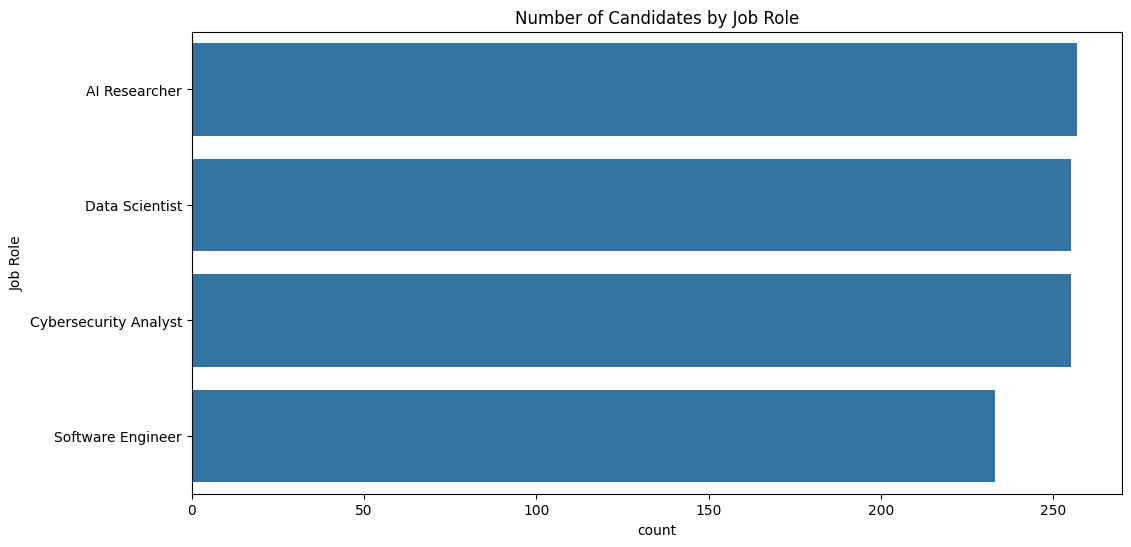

In [138]:
# bar chart
# job role
plt.figure(figsize=(12,6))
sns.countplot(y=df2['Job Role'])
plt.title("Number of Candidates by Job Role")
plt.show()

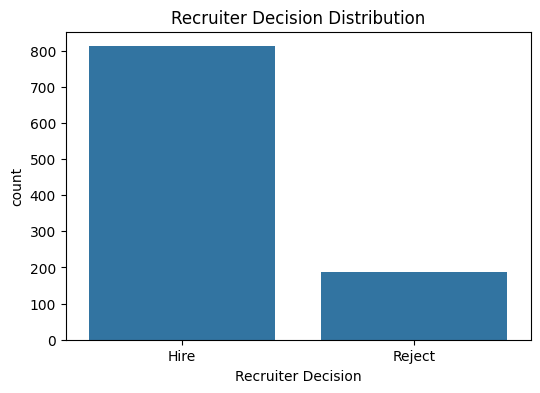

In [139]:
# Recruiter Decision
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Recruiter Decision'])
plt.title("Recruiter Decision Distribution")
plt.show()

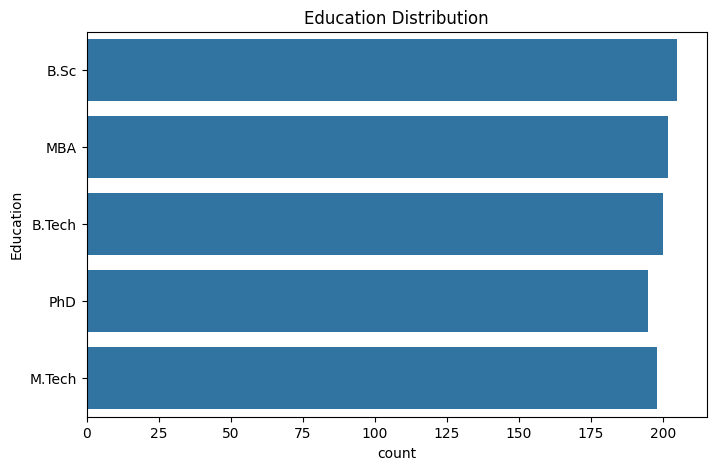

In [140]:
# Education
plt.figure(figsize=(8,5))
sns.countplot(y=df2['Education'])
plt.title("Education Distribution")
plt.show()

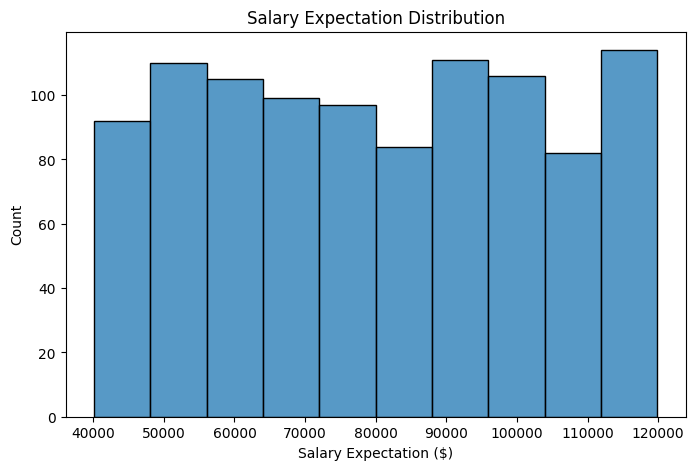

In [141]:
# salary expectation
plt.figure(figsize=(8,5))
sns.histplot(df2['Salary Expectation ($)'], bins=10)
plt.title("Salary Expectation Distribution")
plt.show()

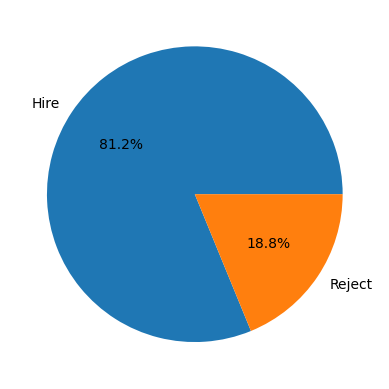

In [142]:
# pie chart
df2['Recruiter Decision'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.show()

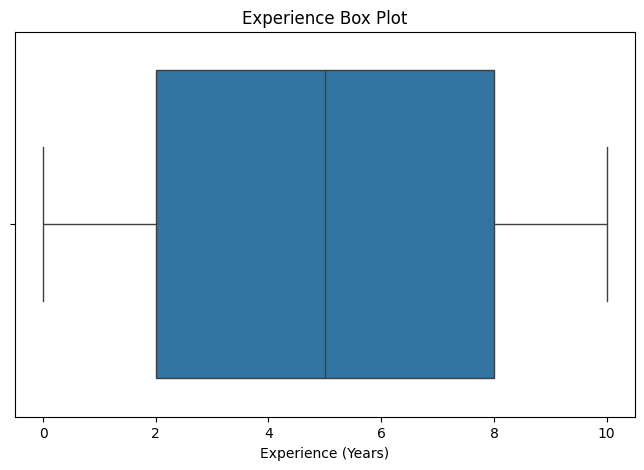

In [143]:
# box plot
plt.figure(figsize=(8,5))
sns.boxplot(x=df2['Experience (Years)'])
plt.title("Experience Box Plot")
plt.show()

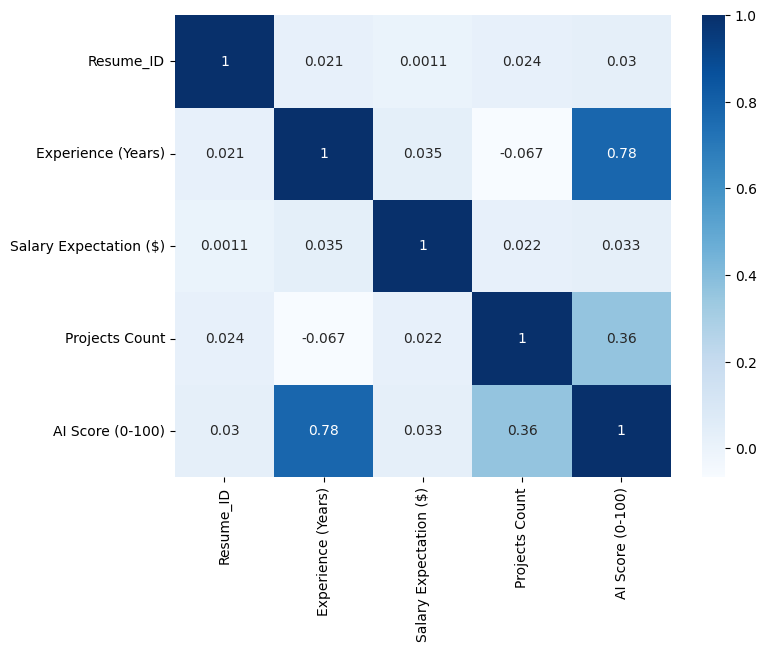

In [144]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df2.select_dtypes(include='number').corr(),
            annot=True,
            cmap='Blues')
plt.show()

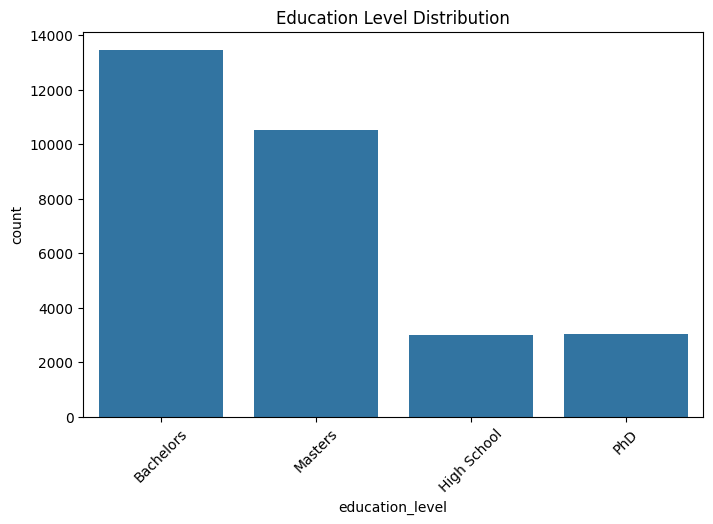

In [145]:
# Education Level
plt.figure(figsize=(8,5))
sns.countplot(x='education_level', data=df1)
plt.title("Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

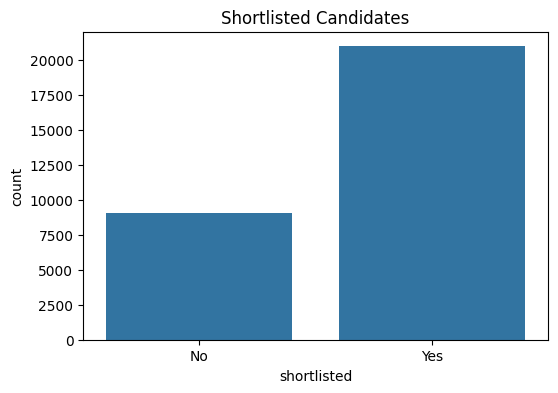

In [146]:
# Shortlisted
plt.figure(figsize=(6,4))
sns.countplot(x='shortlisted', data=df1)
plt.title("Shortlisted Candidates")
plt.show()

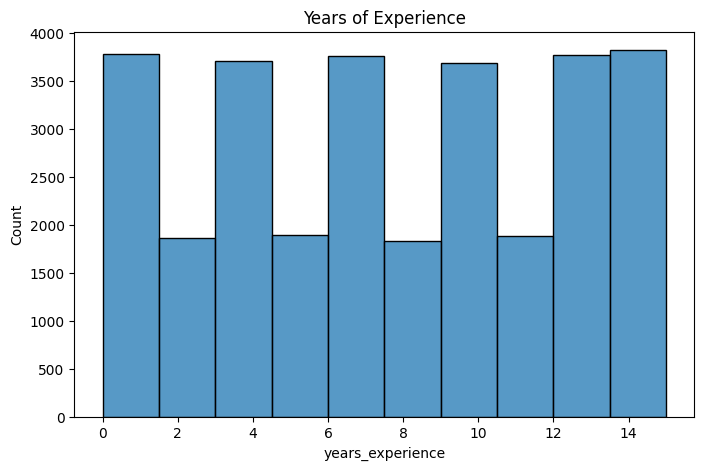

In [147]:
# years of Experience
plt.figure(figsize=(8,5))
sns.histplot(df1['years_experience'], bins=10)
plt.title("Years of Experience")
plt.show()

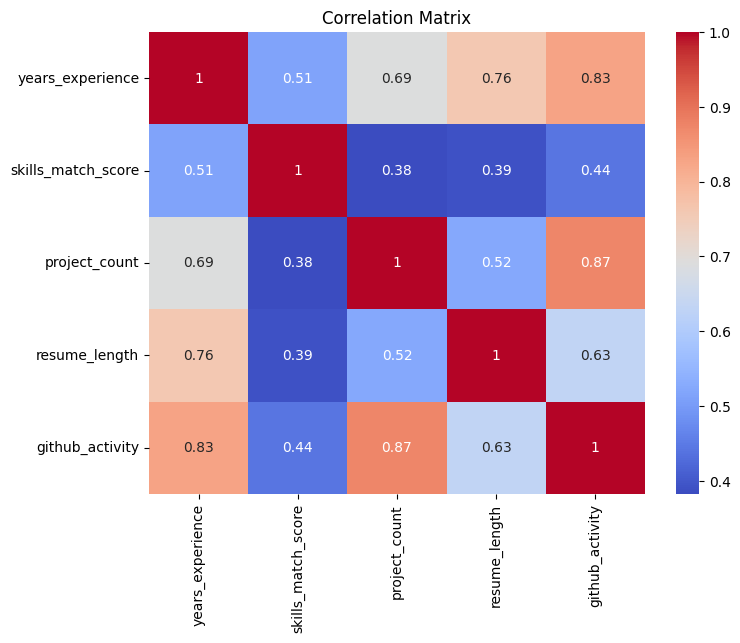

In [148]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

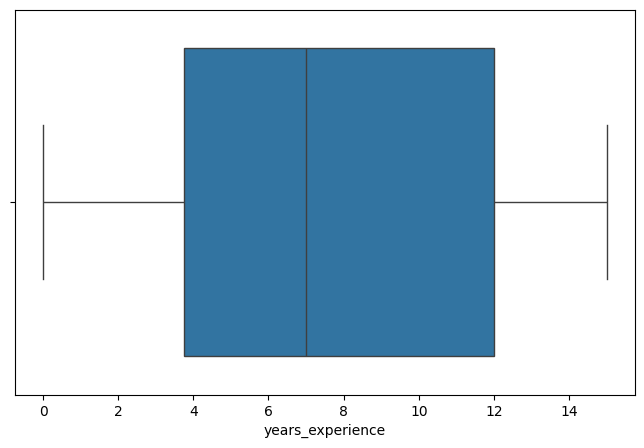

In [149]:
# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x=df1['years_experience'])
plt.show()

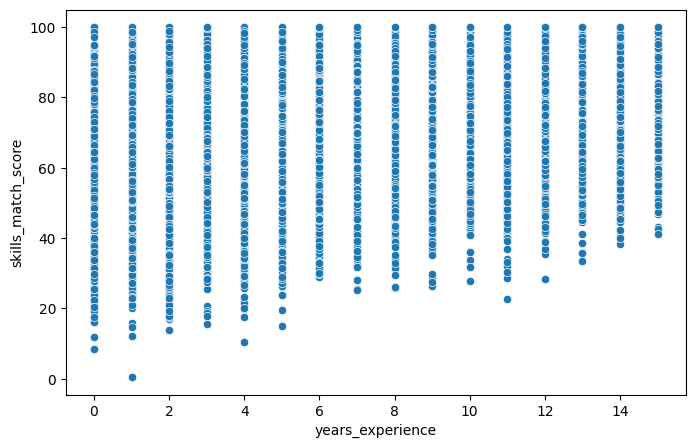

In [150]:
# Scatter Plot
# Experience vs Skills Score
plt.figure(figsize=(8,5))
sns.scatterplot(x='years_experience', y='skills_match_score', data=df1)
plt.show()

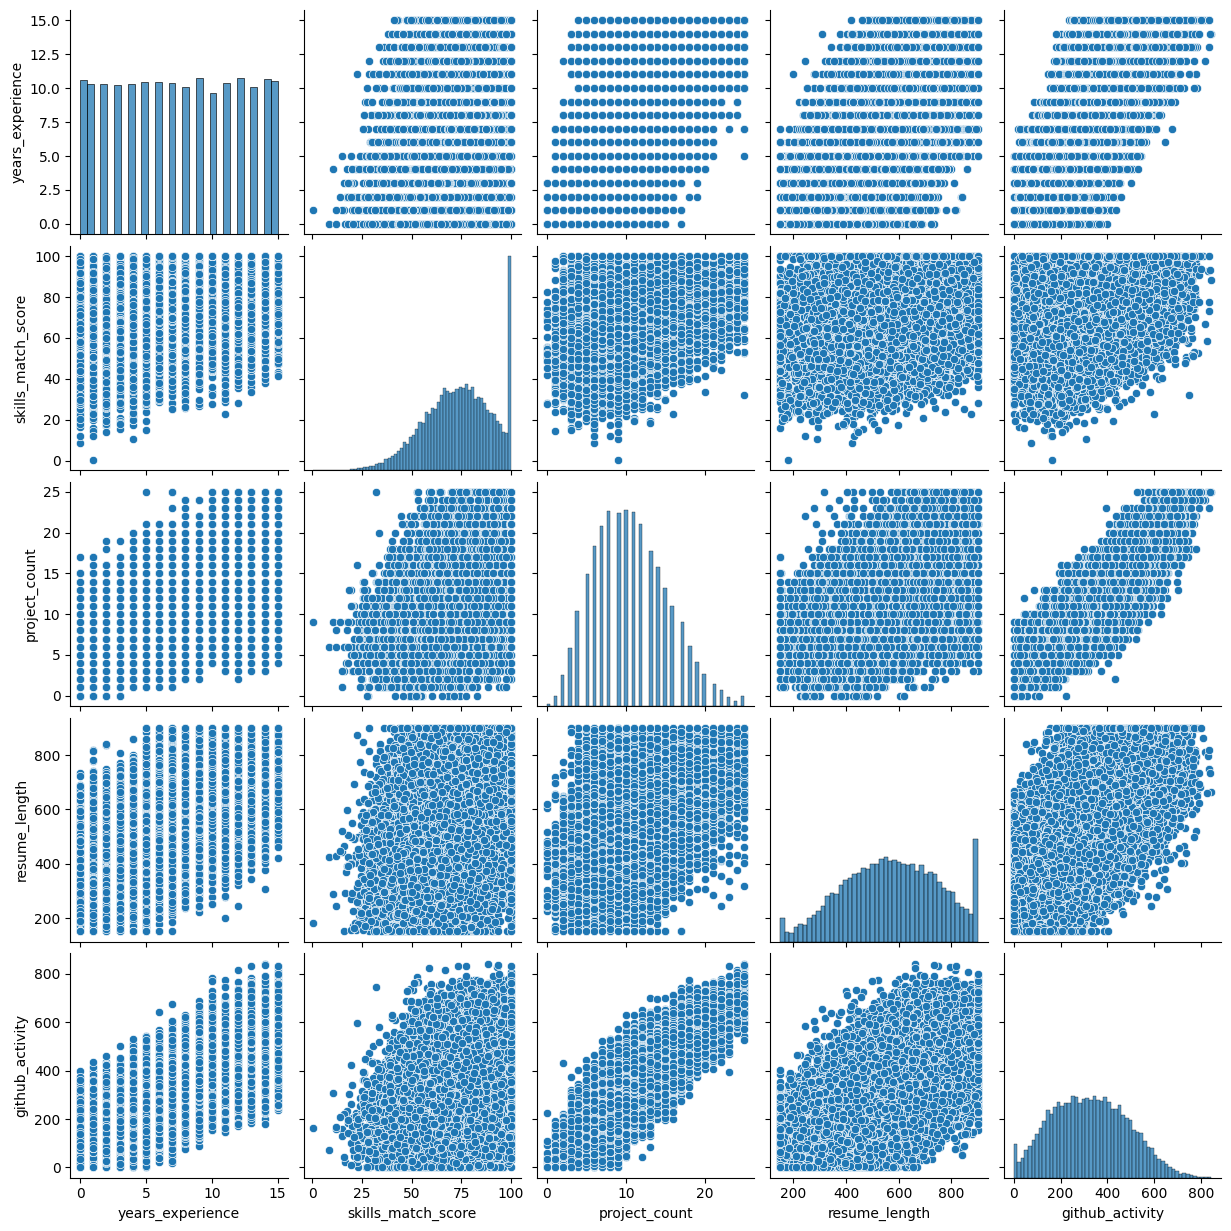

In [151]:
# Pair Plot
sns.pairplot(df1)

In [152]:
# Train-Test Split
X = df1.drop("shortlisted", axis=1)
y = df1["shortlisted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
X = df2['Skills']  # feature for NLP
y = df2['Recruiter Decision']    # target
# convert it into numbers
# TfidfVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df2['Skills'])

In [154]:
# label encoding
encoder = LabelEncoder()
y = encoder.fit_transform(df2['Recruiter Decision'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# for df1

In [155]:
encoder = LabelEncoder()
df1["education_level"] = encoder.fit_transform(df1["education_level"])
df1["shortlisted"] = encoder.fit_transform(df1["shortlisted"])

In [156]:
# features and targets
X = df1.drop("shortlisted", axis=1)
y = df1["shortlisted"]

In [157]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [158]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [159]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [160]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [161]:
print(accuracy_score(y_test, svm_pred))

0.77


In [162]:
print(precision_score(y_test, svm_pred))

0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [163]:
print(recall_score(y_test, svm_pred))

0.0


In [164]:
print(f1_score(y_test, svm_pred))

0.0


In [165]:
cm = confusion_matrix(y_test, svm_pred)

print(cm)

[[154   0]
 [ 46   0]]


In [166]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87       154
           1       0.00      0.00      0.00        46

    accuracy                           0.77       200
   macro avg       0.39      0.50      0.44       200
weighted avg       0.59      0.77      0.67       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [167]:
joblib.dump(svm,"resume_screening_model.pkl")

['resume_screening_model.pkl']

# for df2

In [168]:
# stopwords
stop_words = set(stopwords.words("english"))

In [169]:
# lemmatizer
lemmatizer = WordNetLemmatizer()

In [170]:
# cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [171]:
# Clean Skills
import nltk
nltk.download('punkt_tab') # Ensure 'punkt' tokenizer is available in this context
df2["Clean_Skills"] = df2["Skills"].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [172]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df2["Clean_Skills"])

In [173]:
# Encode Recruiter Decision
encoder = LabelEncoder()
y = encoder.fit_transform(df2["Recruiter Decision"])

In [174]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [175]:
# Train SVM
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [176]:
prediction = svm.predict(X_test)

In [177]:
print(accuracy_score(y_test, prediction))

0.77


In [178]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87       154
           1       0.00      0.00      0.00        46

    accuracy                           0.77       200
   macro avg       0.39      0.50      0.44       200
weighted avg       0.59      0.77      0.67       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [179]:
# Cosine Similarity
resume = "Python Machine Learning SQL"
job = "Python SQL Machine Learning"
vectors = tfidf.fit_transform([resume, job])
similarity = cosine_similarity(vectors[0], vectors[1])
print(similarity * 100)

[[100.]]


In [180]:
# Save Model
joblib.dump(svm,"resume_text_model.pkl")

['resume_text_model.pkl']

In [181]:
# Data Collection
job_description = """
We are looking for a Data Scientist with strong experience in Python, machine learning,
and data visualization. The ideal candidate has hands-on experience with pandas, scikit-learn,
SQL, and building predictive models. Experience deploying models with Flask or Streamlit is
a plus. Strong communication skills and experience presenting insights to stakeholders required.
""" # Defines the job description as a multiline string.

resumes = { # Initializes a dictionary to store resume data.
    "Resume_Anita.txt": "Data Scientist with 3 years of experience building machine learning models in Python...", # Resume content for Anita.
    "Resume_Rahul.txt": "Software engineer with 5 years of experience in Java and backend systems...", # Resume content for Rahul.
    "Resume_Karan.txt":"Marketing analyst with 3 years of experience tracking campaign performance and building reporting dashboards in Excel and PowerPoint", # Resume content for Karan.
    "Resume_Priya.txt":"Machine learning engineer with 4 years of experience building and deploying predictive models in Python.", # Resume content for Priya.

    "Resume_Sneha.txt":"Data analyst with 2 years of experience using Python and pandas for exploratory data analysis and reporting."}

In [182]:
# Text Processing
negation_cues = {"no", "not", "nor", "never", "without", "none"} # Defines a set of words that indicate negation.

def clean_text(text):                # Defines a function to clean and preprocess text.
    text = text.lower()              # Converts the input text to lowercase.
    sentences = re.split(r"[.!?]", text) # Splits the text into sentences using punctuation as delimiters.
    processed_tokens = []            # Initializes an empty list to store processed tokens.
    for sent in sentences:           # Iterates through each sentence.
        words = re.findall(r"[a-z]+", sent) # Extracts all alphabetic words from the sentence.
        negate = False               # Initializes a flag to track negation.
        for w in words:              # Iterates through each word in the sentence.
            if w in negation_cues:   # Checks if the word is a negation cue.
                negate = True        # Sets the negation flag to True.
                continue             # Skips to the next word.
            tagged = f"NEG_{w}" if negate else w # Prefixes the word with 'NEG_' if negation is active, otherwise uses the word as is.
            processed_tokens.append(tagged) # Adds the (potentially tagged) word to the list of processed tokens.
    tokens = [                       # Creates a list of tokens after lemmatization and stop word removal.
        ("NEG_" if t.startswith("NEG_") else "") + lemmatizer.lemmatize(t.replace("NEG_", "")) # Lemmatizes the word, preserving the negation prefix if present.
        for t in processed_tokens    # Iterates through processed tokens.
        if t.replace("NEG_", "") not in stop_words and len(t.replace("NEG_", "")) > 1 # Filters out stop words and single-character words.
    ]                                # Constructs the final list of cleaned tokens.
    return " ".join(tokens)          # Joins the cleaned tokens back into a single string, separated by spaces.

clean_jd = clean_text(job_description) # Cleans the job description using the clean_text function.
clean_resumes = {name: clean_text(text) for name, text in resumes.items()} # Cleans each resume in the 'resumes' dictionary.

In [183]:
# feature extraction
documents = [clean_jd] + list(clean_resumes.values())
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

In [184]:
# similarity scoring
jd_vector = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]
scores = cosine_similarity(jd_vector, resume_vectors)[0]

In [185]:
# ranking
results = pd.DataFrame({"resume": list(clean_resumes.keys()),
    "match_percent": (scores * 100).round(1),
}).sort_values("match_percent", ascending=False)
print(results.to_string(index=False))

          resume  match_percent
Resume_Anita.txt           45.8
Resume_Priya.txt           38.9
Resume_Sneha.txt           23.6
Resume_Karan.txt            6.6
Resume_Rahul.txt            6.1


In [186]:
# explainability
jd_terms = set(clean_jd.split())
for _, row in results.iterrows():
    resume_terms = set(clean_resumes[row["resume"]].split())
    matched = sorted(jd_terms & resume_terms)[:8]
    print(f"{row['resume']:20s} ({row['match_percent']}%): {matched}")

Resume_Anita.txt     (45.8%): ['building', 'data', 'experience', 'learning', 'machine', 'model', 'python', 'scientist']
Resume_Priya.txt     (38.9%): ['building', 'deploying', 'experience', 'learning', 'machine', 'model', 'predictive', 'python']
Resume_Sneha.txt     (23.6%): ['data', 'experience', 'panda', 'python']
Resume_Karan.txt     (6.6%): ['building', 'experience']
Resume_Rahul.txt     (6.1%): ['experience']


In [187]:
import os

print(os.listdir())

['.config', 'dataset2', 'archive (6) (1).zip', 'resume_text_model.pkl', 'label_encoder.pkl', 'resume_screening_model.pkl', 'model.pkl', 'dataset1', 'archive (6).zip', 'archive (5) (1).zip', 'tfidf.pkl', 'archive (5).zip', 'sample_data']


In [188]:
!ls

'archive (5) (1).zip'   dataset1	    resume_screening_model.pkl
'archive (5).zip'       dataset2	    resume_text_model.pkl
'archive (6) (1).zip'   label_encoder.pkl   sample_data
'archive (6).zip'       model.pkl	    tfidf.pkl


In [189]:
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

In [190]:
joblib.dump(svm, "model.pkl")

['model.pkl']

In [191]:
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [192]:
from google.colab import files

files.download("tfidf.pkl")
files.download("model.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [193]:
!pip install nbformat

In [194]:
import os
print(os.listdir())

['.config', 'dataset2', 'archive (6) (1).zip', 'resume_text_model.pkl', 'label_encoder.pkl', 'resume_screening_model.pkl', 'model.pkl', 'dataset1', 'archive (6).zip', 'archive (5) (1).zip', 'tfidf.pkl', 'archive (5).zip', 'sample_data']


In [195]:
!ls

'archive (5) (1).zip'   dataset1	    resume_screening_model.pkl
'archive (5).zip'       dataset2	    resume_text_model.pkl
'archive (6) (1).zip'   label_encoder.pkl   sample_data
'archive (6).zip'       model.pkl	    tfidf.pkl


In [196]:
!grep -R "TfidfVectorizer" -n .

grep: ./tfidf.pkl: binary file matches


In [197]:
!grep -R "LabelEncoder" -n .

grep: ./label_encoder.pkl: binary file matches
